In [1]:
import os
num_threads = "8"
os.environ["OMP_NUM_THREADS"] = num_threads
os.environ["OPENBLAS_NUM_THREADS"] = num_threads
os.environ["MKL_NUM_THREADS"] = num_threads
os.environ["VECLIB_MAXIMUM_THREADS"] = num_threads
os.environ["NUMEXPR_NUM_THREADS"] = num_threads

import numpy as np
import scipy as sp
import scanpy as sc
import anndata as ad
import pandas as pd
import os
import matplotlib.pyplot as plt
import sys
import scvelo as scv
import torch
sys.path.append("../src/")
import rf
import util
import ot
import sklearn as sk
import geomloss
from umap import UMAP
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
#adata = sc.read('/mnt/c/users/yannm/ubuntu_conda/data/schiebinger/schiebinger_100k_100g.h5ad')
#adata = sc.read('/mnt/c/users/yannm/ubuntu_conda/data/cardasc_output/schiebinger_10k_DE_time.h5ad')
#adata.X = adata.X.todense()
adata = sc.read("/mnt/c/users/yannm/ubuntu_conda/benchmark/data/BN8/data_1.h5ad")

In [3]:
np.unique(adata.obs['t'])

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [4]:
#Choose train and test timepoints
train_tps = np.linspace(0, 44, 45, dtype='int')
test_tps = np.linspace(45, 49, 5, dtype='int')

In [5]:
adata_train = adata[adata.obs['t'].isin(train_tps),:]

In [6]:
np.unique(adata_train.obs['t'])

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44])

list_t = []
for i in adata_train.obs['t']:
    i = i/2
    list_t.append(i)
adata_train.obs['t'] = list_t

In [7]:
options = {
    "lr" : 0.05, 
    "reg_sinkhorn" : 0.1,
    "reg_A" : 1, 
    "reg_A_elastic" : 0.5, 
    "iter" : 4000,
    "ot_coupling" : True,
    "optimizer" : torch.optim.Adam,
    "n_pca_components" : -1
}

In [8]:
estim_alt_wt = rf.Estimator([adata_train], kos = [None],
                           lr = options["lr"],
                           reg_sinkhorn = options["reg_sinkhorn"], 
                           reg_A = options["reg_A"], 
                           reg_A_elastic = options["reg_A_elastic"], 
                           iter = options["iter"], 
                           ot_coupling = options["ot_coupling"],
                           optimizer = options["optimizer"],
                           norm = False)
estim_alt_wt.fit(print_iter=100, alg = "alternating", update_couplings_iter=250);

Updating transport plans
iteration 0, loss = -20872.308966969445, L = -20872.308966969445, R = 0.0
iteration 100, loss = -21630.58262806819, L = -21648.80941374092, R = 18.226785672728827
iteration 200, loss = -21890.03728751206, L = -21929.034994844198, R = 38.99770733214035
iteration 300, loss = -22082.043228559847, L = -22142.641911416416, R = 60.59868285657019
iteration 400, loss = -22139.70813987071, L = -22217.67183459053, R = 77.96369471981913
iteration 500, loss = -22173.859172449284, L = -22262.172271547668, R = 88.31309909838558
iteration 600, loss = -22189.404674554244, L = -22287.809111062714, R = 98.40443650846989
iteration 700, loss = -22195.174976820363, L = -22299.41781133872, R = 104.24283451835873
iteration 800, loss = -22201.240607192452, L = -22308.83813049538, R = 107.59752330292912
iteration 900, loss = -22203.275929610616, L = -22313.922056992622, R = 110.64612738200775
iteration 1000, loss = -22204.798061850026, L = -22317.21073255962, R = 112.41267070959134
ite

In [9]:
#Calculate a new timepoint with adata corresponding to one dataset (ctrl or ko)
def future_pred(estimator, adata, T_start, n_timepoints):
    Xs_copy = estimator.Xs[adata].copy()[T_start]
    Xs_pred = [Xs_copy]
    A = estimator.A * estimator.Ms[adata]
    b = estimator.b * estimator.Ms[adata][0, :]
    t = 1 /estimator.T
    P = torch.linalg.matrix_exp(t*A)
    for n in range(n_timepoints):
        future_pred = torch.relu(((Xs_pred[n] / estimator.std) @ P + t * b) * estimator.std)
        Xs_pred.append(future_pred)
    return Xs_pred

In [10]:
def Wasserstein(true_data, pred_data):
    '''Evaluate the Wasserstein distance between true and reconstructed data at a single time point.'''
    assert true_data.shape[1] == pred_data.shape[1]
    ot_solver = geomloss.SamplesLoss("sinkhorn", p=2, blur=0.05, scaling=0.5, debias=True, backend="tensorized")
    # ot_solver = SamplesLoss("sinkhorn", p=2, blur=0.05, scaling=1.0, debias=True, backend="tensorized")
    if isinstance(true_data, np.ndarray):
        true_data = torch.DoubleTensor(true_data)
    if isinstance(true_data, torch.FloatTensor):
        true_data = torch.DoubleTensor(true_data.detach().numpy())
    if isinstance(pred_data, np.ndarray):
        pred_data = torch.DoubleTensor(pred_data)
    if isinstance(pred_data, torch.FloatTensor):
        pred_data = torch.DoubleTensor(pred_data.detach().numpy())
    ot_loss = ot_solver(true_data, pred_data).item()
    return ot_loss

In [11]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# Full pred from t=0

In [14]:
pred_data = future_pred(estim_alt_wt, 0, 0, 36)

In [15]:
pred_array = np.array([pred_data[i].cpu().numpy() for i in range(len(pred_data))])
pred_array = np.reshape(pred_array, newshape = (len(pred_data)*len(adata_train[adata_train.obs['t']==0]), adata_train.shape[1]))
list_times_pred = []
for i in range(len(pred_data)):
    list_times_pred+= [i] * len(adata_train[adata_train.obs['t']==0])
pred_adata = ad.AnnData(pred_array)
pred_adata.obs['t'] = list_times_pred
sc.pp.normalize_total(pred_adata)
sc.pp.log1p(pred_adata)

In [17]:
list_wasserstein = []
for i in range(len(np.unique(adata.obs['t']))):
    list_wasserstein.append(Wasserstein(adata[adata.obs['t']==i].X, pred_adata[pred_adata.obs['t']==i].X))

# Extrapol from end of training timepoints

In [11]:
train_tps

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44])

In [12]:
test_tps

array([45, 46, 47, 48, 49])

In [14]:
pred_data = future_pred(estim_alt_wt, 0, test_tps[0]-1, len(test_tps))

In [13]:
pred_data = future_pred(estim_alt_wt, 0, len(train_tps)-1, len(test_tps))

In [ ]:
pred_array = np.array([pred_data[i].cpu().numpy() for i in range(len(pred_data))])
pred_array = np.reshape(pred_array, newshape = (len(pred_data)*len(adata_train[adata_train.obs['t']==test_tps[0]-1]), adata_train.shape[1]))
list_times_pred = []
for i in range(len(pred_data)):
    list_times_pred+= [len(train_tps)-1+i] * len(adata_train[adata_train.obs['t']==test_tps[0]-1])
pred_adata = ad.AnnData(pred_array)
pred_adata.obs['t'] = list_times_pred
pred_adata = pred_adata[pred_adata.obs['t']!=len(train_tps)-1].copy()

In [ ]:
sc.pp.normalize_total(pred_adata)
sc.pp.log1p(pred_adata)

In [19]:
pred_adata.write_h5ad('/mnt/c/users/yannm/ubuntu_conda/methods_outputs/reffit_extrapol_20_10k_t.h5ad')

In [ ]:
list_wasserstein = []
for i in range(len(test_tps)):
    list_wasserstein.append(Wasserstein(adata[adata.obs['t']==test_tps[i]].X, pred_adata[pred_adata.obs['t']==test_tps[i]].X))

In [44]:
np.save('/mnt/c/users/yannm/ubuntu_conda/methods_outputs/reffit_extrapol_20_10k_t', list_wasserstein)

In [45]:
t = 1/estim_alt_wt.T
P = torch.linalg.matrix_exp(t*estim_alt_wt.A)
grn = P.cpu().numpy()
np.save('/mnt/c/users/yannm/ubuntu_conda/methods_outputs/reffit_extrapol_20_10k_t_GRN', list_wasserstein)

# Interpol Pred neighbor

In [57]:
#Calculate a new timepoint with adata corresponding to one dataset (ctrl or ko)
def interpol_pred(estimator, adata, T_start):
    Xs_copy = estimator.Xs[adata].copy()
    A = estimator.A * estimator.Ms[adata]
    b = estimator.b * estimator.Ms[adata][0, :]
    t = 1 /estimator.T
    P = torch.linalg.matrix_exp(t*A*0.5) #Half time
    interpol_pred = torch.relu(((Xs_copy[T_start] / estimator.std) @ P + t * b) * estimator.std)+1e-6
    return interpol_pred

In [58]:
list_wasserstein = []
for i in range(len(test_tps)):
    pred_data = interpol_pred(estim_alt_wt, 0, i)
    pred_array = np.array(pred_data.cpu().numpy())
    list_times_pred = []
    pred_adata = ad.AnnData(pred_array)
    sc.pp.normalize_total(pred_adata)
    sc.pp.log1p(pred_adata)
    list_wasserstein.append(Wasserstein(adata[adata.obs['t']== 2*i+1].X, pred_adata.X))

In [59]:
list_wasserstein

[36.00917673424681,
 31.182246320049657,
 40.43567036383668,
 39.611480982476024,
 38.4382949140489,
 82.14844316990497,
 79.21535722106316,
 69.81305541195209,
 31.135863696990686,
 54.59876235144165,
 38.599685882361186,
 39.715625259627814,
 47.76549289141609,
 79.33284698853763,
 55.62363479737265,
 42.2222649880278,
 39.13721918473776,
 49.89077750478734]

In [60]:
np.mean(list_wasserstein)

np.float64(49.71532770349327)

In [61]:
np.save('/mnt/c/users/yannm/ubuntu_conda/methods_outputs/reffit_interpol_10k_t', list_wasserstein)

# Plot wasserstein-test timepoints

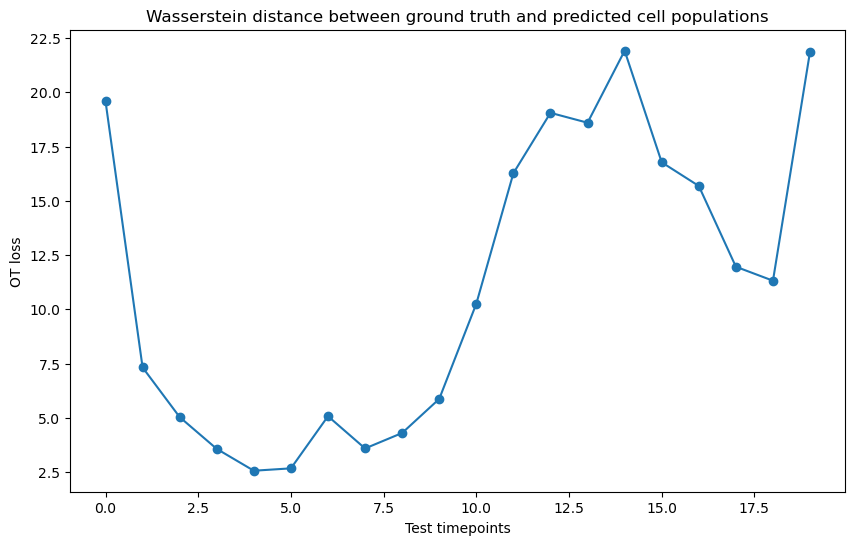

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(list_wasserstein, marker='o')
plt.xlabel('Test timepoints')
plt.ylabel('OT loss')
plt.title('Wasserstein distance between ground truth and predicted cell populations')
plt.grid(False)
plt.savefig("/mnt/c/users/yannm/documents/COMPO/project/reference_fit/Wasserstein_prediction_interpol")
#plt.show()

# Plot Heatmap train timepoints - test timepoints

In [22]:
#Ground truth array
true_heatmap_array = []
for i, test in enumerate(test_tps):
    print(i)
    true_heatmap_array.append([])
    for train in train_tps:
        true_heatmap_array[i].append(Wasserstein(adata[adata.obs['t']== train].X, adata[adata.obs['t'] == test].X))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [ ]:
#Pred array
pred_heatmap_array = []
for i, test in enumerate(test_tps):
    pred_data = interpol_pred(estim_alt_wt, 0, int((test-1)/2))
    pred_heatmap_array.append([])
    for train in train_tps:
        pred_heatmap_array[i].append(Wasserstein(adata[adata.obs['t']==train].X, pred_data))

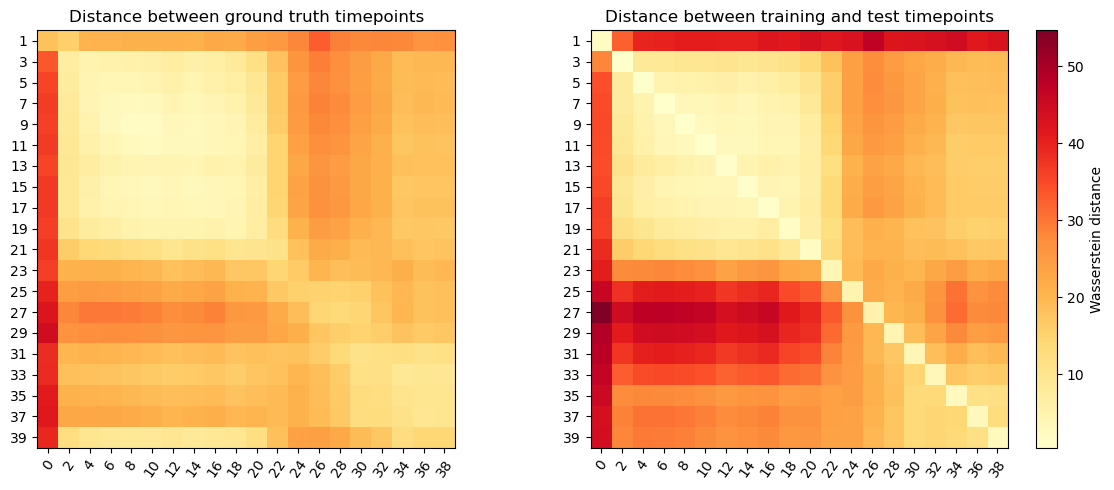

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

global_min = min(np.min(true_heatmap_array), np.min(pred_heatmap_array))
global_max = max(np.max(true_heatmap_array), np.max(pred_heatmap_array))

im1 = axes[0].imshow(true_heatmap_array, cmap = "YlOrRd", vmin=global_min, vmax=global_max)
axes[0].set_title("Distance between ground truth timepoints", fontsize=12)
axes[0].set_xticks(range(len(train_tps)), labels=train_tps, rotation=55)
axes[0].set_yticks(range(len(test_tps)), labels=test_tps)
im2 = axes[1].imshow(pred_heatmap_array, cmap = "YlOrRd", vmin=global_min, vmax=global_max)
axes[1].set_title("Distance between training and test timepoints", fontsize=12)
axes[1].set_xticks(range(len(train_tps)), labels=train_tps, rotation=55)
axes[1].set_yticks(range(len(test_tps)), labels=test_tps)
fig.colorbar(im2, ax=axes[1], label='Wasserstein distance')
axes[0].grid(False)
axes[1].grid(False)
plt.tight_layout()
plt.savefig("/mnt/c/users/yannm/documents/COMPO/project/flecs/heatmaps_flecs_base_model")
#plt.show()

# Plot UMAP pred/timepoint

In [36]:
reorder_pred_data = [i.detach().numpy() for i in pred_data]
true_data = [adata[adata.obs['t']== time,:].X.copy() for time in np.unique(adata.obs['t'])]

In [49]:
len(true_data)

40

In [50]:
def plot_UMAP_pred_true(true_data, pred_data, start, end, compare, point_size):
    true_cell_tps = np.concatenate([np.repeat(t+start, each.shape[0]) for t, each in enumerate(true_data[slice(start, end+1)])])
    pred_cell_tps = np.concatenate([np.repeat(t+start, each.shape[0]) for t, each in enumerate(reorder_pred_data[slice(start, end+1)])])
    pca_model = PCA(n_components=50, svd_solver="arpack")
    umap_model = UMAP(n_components=2, n_neighbors=50)
    true_umap_traj = umap_model.fit_transform(pca_model.fit_transform(np.concatenate(true_data[slice(start, end+1)], axis=0)))
    pred_umap_traj = umap_model.transform(pca_model.transform(np.concatenate(pred_data[slice(start, end+1)], axis=0)))
    
    cm = plt.get_cmap("viridis")
    color_list = [cm(i//3*3.0/len(compare)) for i in range(len(compare))]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.set_title("True Data", fontsize=15)
    ax2.set_title("Predictions", fontsize=15)
    ax1.scatter(true_umap_traj[:, 0], true_umap_traj[:, 1], label="other", c='gray', s=point_size, alpha=0.5)
    ax2.scatter(true_umap_traj[:, 0], true_umap_traj[:, 1], label="other", c='gray', s=point_size, alpha=0.5)
    for i, t in enumerate(compare):
        color = color_list[i]
        true_t_idx = np.where(true_cell_tps == t)[0]
        pred_t_idx = np.where(pred_cell_tps == t)[0]
        ax1.scatter(true_umap_traj[true_t_idx, 0], true_umap_traj[true_t_idx, 1], label=int(t), color=color, s=point_size, alpha=1.0)
        ax2.scatter(pred_umap_traj[pred_t_idx, 0], pred_umap_traj[pred_t_idx, 1], label=int(t), color=color, s=point_size, alpha=1.0)
    ax2.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
    # plt.tight_layout()
    ax1.grid(visible=False)
    ax2.grid(visible=False)
    plt.savefig("/mnt/c/users/yannm/documents/COMPO/project/reference_fit/extrapol_10")
    #plt.show()

In [ ]:
plot_UMAP_pred_true(true_data, reorder_pred_data, start=0, end=39, compare=[10], point_size=10)

In [31]:
adata

AnnData object with n_obs × n_vars = 100000 × 100
    obs: 'day', 'treatment', 'n_genes', 't'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'